In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
#dataset paths
train_dir = "/content/drive/MyDrive/AI ML/Data/seg_train/seg_train"
test_dir = "/content/drive/MyDrive/AI ML/Data/seg_test/seg_test"


In [3]:
#image setting
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [4]:
#image data generator
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
#load train data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 11230 images belonging to 6 classes.


In [6]:
#load validation data
val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2804 images belonging to 6 classes.


In [7]:
#load test data
test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [8]:
#class information
class_names = list(train_data.class_indices.keys())
num_classes = len(class_names)

print("\nClass Names:")
print(class_names)


Class Names:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
#dataset information
print("\nTotal Training Images:", train_data.samples)
print("Total Validation Images:", val_data.samples)
print("Total Testing Images:", test_data.samples)



Total Training Images: 11230
Total Validation Images: 2804
Total Testing Images: 3000


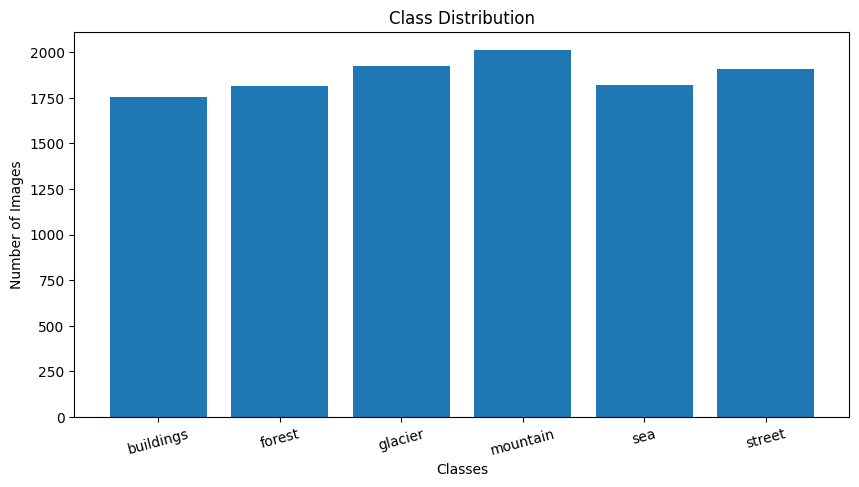

In [10]:
#display class distribution

class_counts = np.bincount(train_data.classes)

plt.figure(figsize=(10,5))

plt.bar(class_names, class_counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

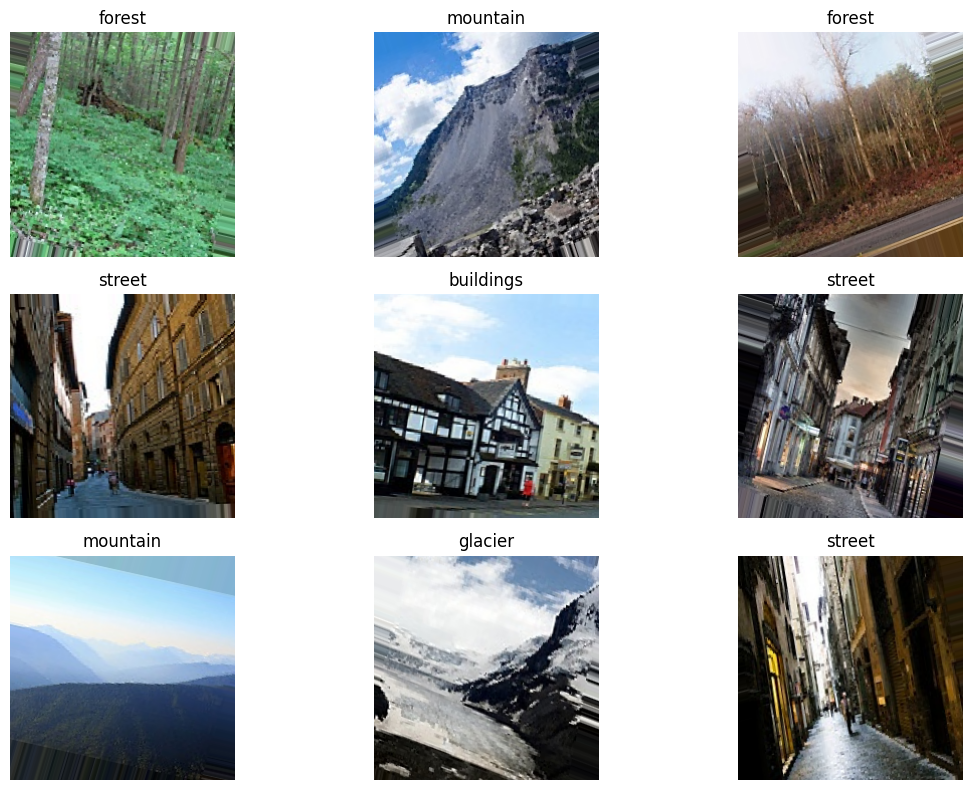

In [11]:
#display sample images
images, labels = next(train_data)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()
plt.show()


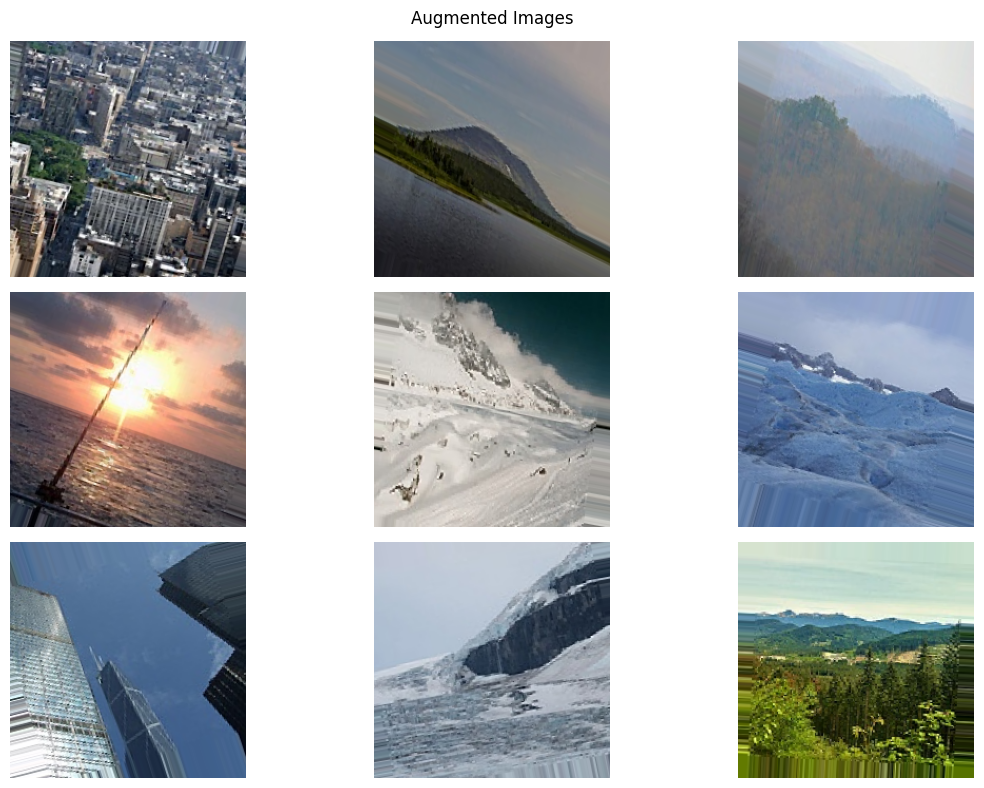

In [12]:
#display agumented images
aug_images, _ = next(train_data)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(aug_images[i])

    plt.axis("off")

plt.suptitle("Augmented Images")

plt.tight_layout()
plt.show()

In [13]:
#early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [14]:
#baseline CNN model
baseline_model = Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
#compile baseline model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
#baseline model summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,494 (42.65 MB)

 Trainable params: 11,179,494 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#train baseline model
start_time = time.time()

history_base = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

end_time = time.time()

baseline_training_time = end_time - start_time

print("\nBaseline Model Training Time:")
print(baseline_training_time)


Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 8614s 25s/step - accuracy: 0.5791 - loss: 1.0731 - val_accuracy: 0.6512 - val_loss: 0.9140
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1633s 5s/step - accuracy: 0.6887 - loss: 0.8337 - val_accuracy: 0.7254 - val_loss: 0.7559
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1646s 5s/step - accuracy: 0.7397 - loss: 0.7124 - val_accuracy: 0.7578 - val_loss: 0.6645
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1638s 5s/step - accuracy: 0.7625 - loss: 0.6433 - val_accuracy: 0.7653 - val_loss: 0.6235
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1630s 5s/step - accuracy: 0.7844 - loss: 0.5867 - val_accuracy: 0.8006 - val_loss: 0.5688
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1663s 5s/step - accuracy: 0.8040 - loss: 0.5372 - val_accuracy: 0.7710 - val_loss: 0.6482
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1682s 5s/step - accuracy: 0.8129 - loss: 0.5193 - val_accuracy: 0.8085 - val_loss: 0.5369
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1687s 5s/step - accuracy: 0.8279 - loss: 0.4776 -

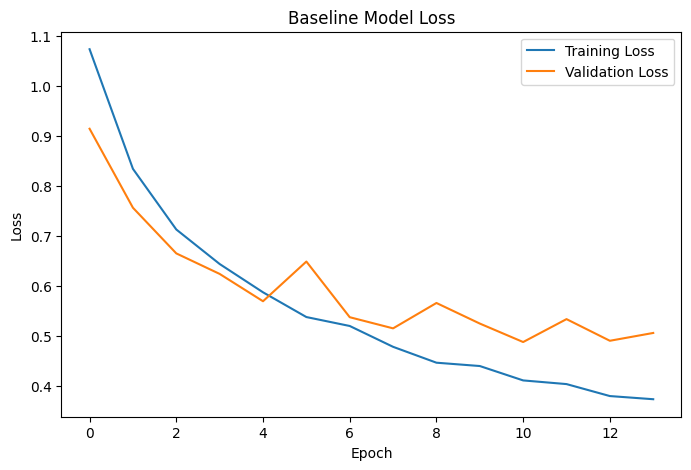

In [18]:
#baseline loss curve
plt.figure(figsize=(8,5))

plt.plot(
    history_base.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_base.history['val_loss'],
    label='Validation Loss'
)

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()


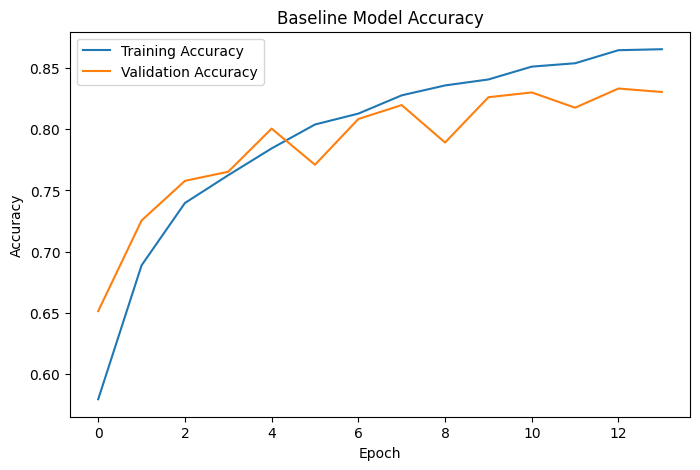

In [19]:
#baseline accuracy curve
plt.figure(figsize=(8,5))

plt.plot(
    history_base.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_base.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [20]:
#baseline model evaluation
baseline_loss, baseline_accuracy = baseline_model.evaluate(test_data)

print("\nBaseline Test Accuracy:")
print(baseline_accuracy)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1860s 20s/step - accuracy: 0.8313 - loss: 0.4815

Baseline Test Accuracy:
0.831333339214325


In [21]:
#baseline predictions
y_true = test_data.classes

y_pred_prob = baseline_model.predict(test_data)

y_pred = np.argmax(y_pred_prob, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step


In [22]:
#baseline classification report
print("\nBaseline Classification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


Baseline Classification Report:

              precision    recall  f1-score   support

   buildings       0.79      0.84      0.82       437
      forest       0.96      0.96      0.96       474
     glacier       0.89      0.70      0.78       553
    mountain       0.81      0.74      0.78       525
         sea       0.73      0.90      0.81       510
      street       0.84      0.87      0.85       501

    accuracy                           0.83      3000
   macro avg       0.84      0.84      0.83      3000
weighted avg       0.84      0.83      0.83      3000



In [25]:
#bBaseline model summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,538,484 (127.94 MB)

 Trainable params: 11,179,494 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,358,990 (85.29 MB)

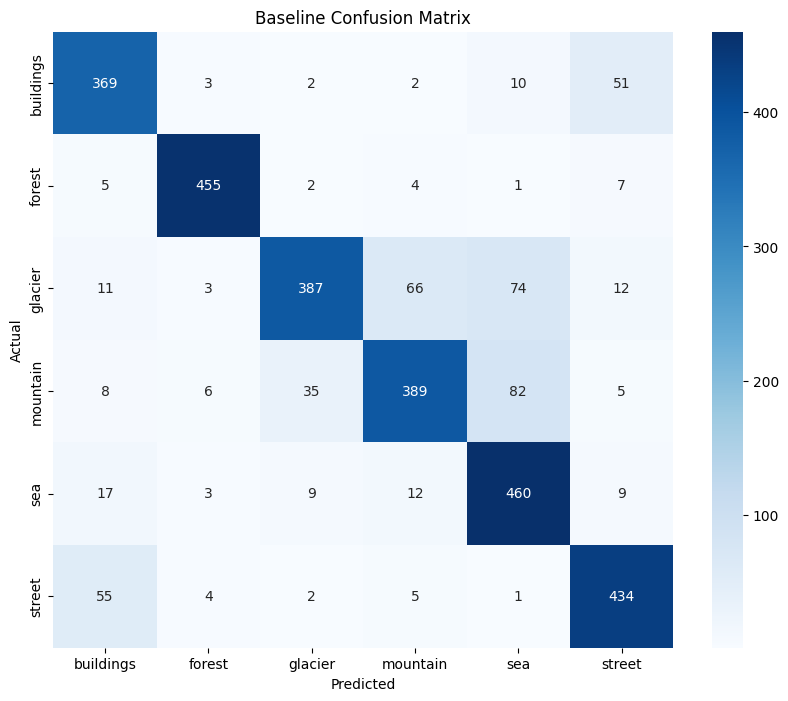

In [26]:
#baseline confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 993ms/step


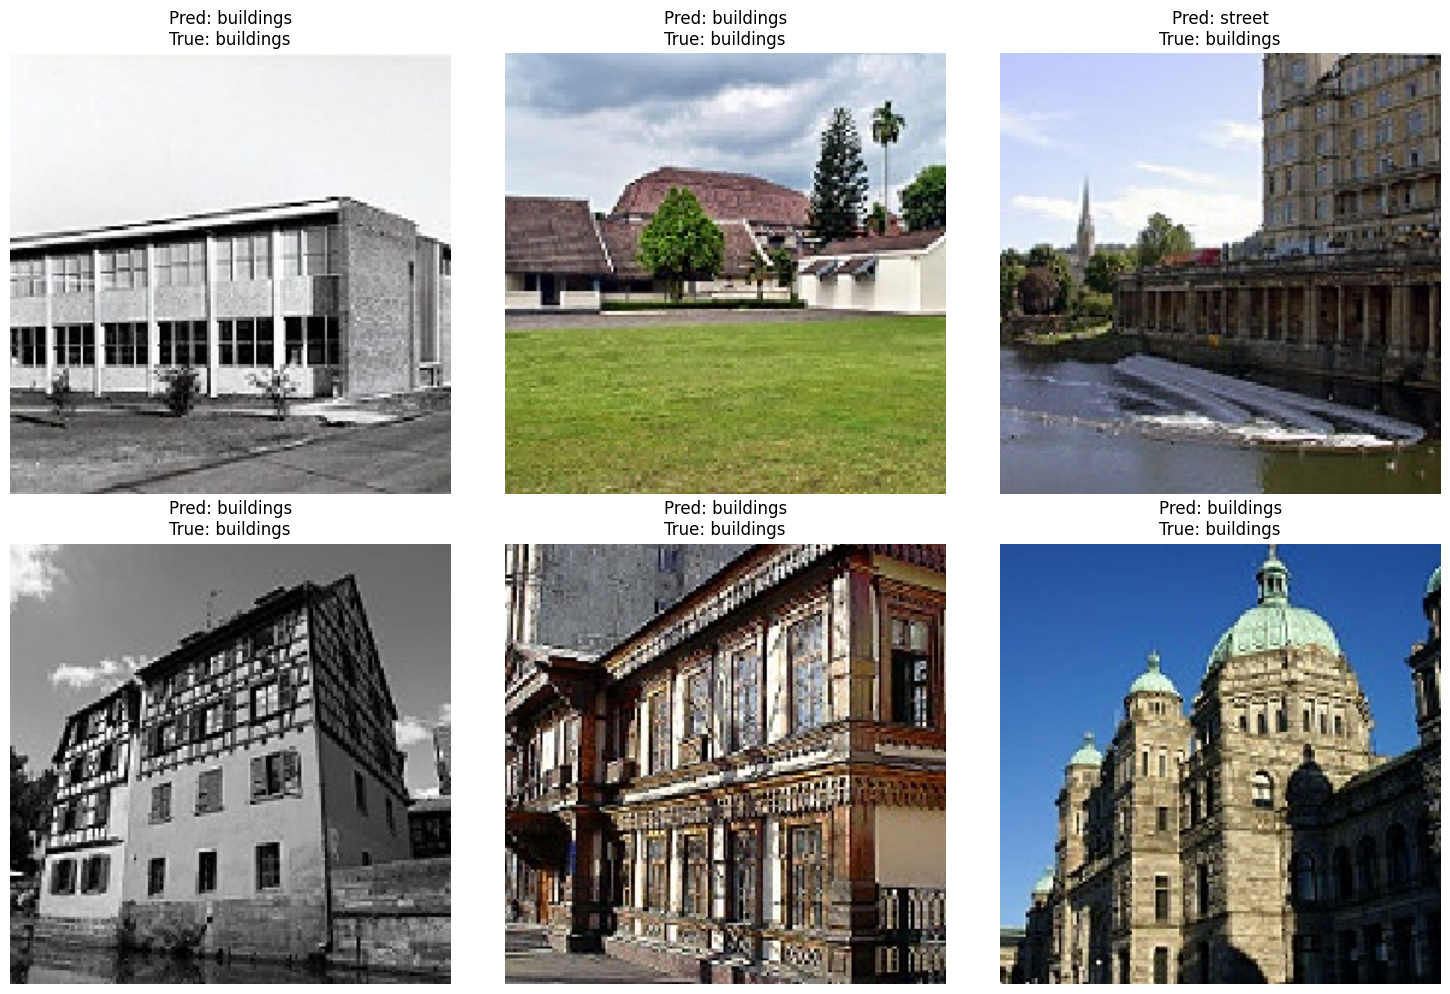

In [27]:
#sample predictions
images, labels = next(test_data)

predictions = baseline_model.predict(images)

plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[np.argmax(labels[i])]

    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
#deep CNN model
deep_model = Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
#compile deep model
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [30]:
#deep model summary
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,196,198 (73.23 MB)

 Trainable params: 19,195,750 (73.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#train deep model
start_time = time.time()

history_deep = deep_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

end_time = time.time()

deep_training_time = end_time - start_time

print("\nDeep Model Training Time:")
print(deep_training_time)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 5056s 14s/step - accuracy: 0.2563 - loss: 2.7372 - val_accuracy: 0.2347 - val_loss: 1.7008
Epoch 2/15
150/351 ━━━━━━━━━━━━━━━━━━━━ 44:57 13s/step - accuracy: 0.2157 - loss: 1.8046

In [ ]:
#deep model loss curve
plt.figure(figsize=(8,5))

plt.plot(
    history_deep.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_deep.history['val_loss'],
    label='Validation Loss'
)

plt.title("Deep Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()


In [ ]:
#deep model accuracy curve
plt.figure(figsize=(8,5))

plt.plot(
    history_deep.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_deep.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Deep Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
#deep model evaluation
deep_loss, deep_accuracy = deep_model.evaluate(test_data)

print("\nDeep Model Accuracy:")
print(deep_accuracy)

In [ ]:
#SGD Optimizer analysis
deep_model_sgd = keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deep_model_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

sgd_loss, sgd_accuracy = deep_model_sgd.evaluate(test_data)

print("\nSGD Model Accuracy:")
print(sgd_accuracy)

In [ ]:
#ablation study
#remove dropout
ablation_model = Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

ablation_loss, ablation_accuracy = ablation_model.evaluate(test_data)

print("\nAblation Model Accuracy:")
print(ablation_accuracy)


In [ ]:
#transfer learning using VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
#Freeze pretrained Layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
#Build Transfer Model
x = layers.GlobalAveragePooling2D()(base_model.output)

x = layers.Dense(
    256,
    activation='relu'
)(x)

x = layers.Dropout(0.5)(x)

output = layers.Dense(
    num_classes,
    activation='softmax'
)(x)

transfer_model = keras.Model(
    inputs=base_model.input,
    outputs=output
)


In [ ]:
#Compile Transfer model
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
#Transfer model Summary
transfer_model.summary()

In [ ]:
#Feature Extraction Training
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

In [ ]:
#fine tuning
for layer in base_model.layers[-5:]:
    layer.trainable = True

transfer_model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


In [ ]:
#Transfer model evaluation
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_data)

print("\nTransfer Learning Accuracy:")
print(transfer_accuracy)

In [ ]:
#Transfer model Classification Report
y_pred_transfer = np.argmax(
    transfer_model.predict(test_data),
    axis=1
)

print("\nTransfer Learning Classification Report:\n")

print(classification_report(
    y_true,
    y_pred_transfer,
    target_names=class_names
))


In [ ]:
#Transfer model Confusion matrix
cm_transfer = confusion_matrix(
    y_true,
    y_pred_transfer
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_transfer,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
#performance metrics
baseline_precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

baseline_recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

baseline_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

deep_pred = np.argmax(
    deep_model.predict(test_data),
    axis=1
)

deep_precision = precision_score(
    y_true,
    deep_pred,
    average='weighted'
)

deep_recall = recall_score(
    y_true,
    deep_pred,
    average='weighted'
)

deep_f1 = f1_score(
    y_true,
    deep_pred,
    average='weighted'
)

transfer_precision = precision_score(
    y_true,
    y_pred_transfer,
    average='weighted'
)

transfer_recall = recall_score(
    y_true,
    y_pred_transfer,
    average='weighted'
)

transfer_f1 = f1_score(
    y_true,
    y_pred_transfer,
    average='weighted'
)


In [ ]:
#comparision table
results = pd.DataFrame({

    "Model": [
        "Baseline CNN",
        "Deep CNN",
        "Transfer Learning"
    ],

    "Accuracy": [
        baseline_accuracy,
        deep_accuracy,
        transfer_accuracy
    ],

    "Precision": [
        baseline_precision,
        deep_precision,
        transfer_precision
    ],

    "Recall": [
        baseline_recall,
        deep_recall,
        transfer_recall
    ],

    "F1 Score": [
        baseline_f1,
        deep_f1,
        transfer_f1
    ]
})

print("\nMODEL COMPARISON TABLE\n")

print(results)

In [ ]:
#Model Accuracy Comparison graph
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()


In [ ]:
#training time comparison
print("\nTraining Time Comparison")

print("\nBaseline Model Time:")
print(baseline_training_time)

print("\nDeep Model Time:")
print(deep_training_time)

In [ ]:
print("\nTraining performed using Google Colab GPU.")